In [2]:
# importing libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [5]:
#import data
df = pd.read_csv('data/stud.csv')

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
# shape
df.shape

(1000, 8)

#### Basic EDA

In [ ]:
# checks to perform
# check missing values
# check duplicates
# check data type
# check number of unique values of each column
# check stats of data
# check various categories present in different categorical columns

In [ ]:
# check for nums - no nans
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [ ]:
# check duplicates - no duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info() # checking info

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [11]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [ ]:
df.describe() # stats of dataset

# min score of maths is lowest 0, followed  by writing and reading
# avg score is nearby for all ~68
# not much diff in std dev

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [93]:
# exploring the data  - unique values
print('unique values of gender column - ',list(df['gender'].unique()))
print('unique values of race_ethnicity column - ',list(df['race_ethnicity'].unique()))
print('unique values of lunch column - ',list(df['lunch'].unique()))
print('unique values of parental_level_of_education column - ',list(df['parental_level_of_education'].unique()))
print('unique values of test_preparation_course column - ',list(df['test_preparation_course'].unique()))

unique values of gender column -  ['female', 'male']
unique values of race_ethnicity column -  ['group B', 'group C', 'group A', 'group D', 'group E']
unique values of lunch column -  ['standard', 'free/reduced']
unique values of parental_level_of_education column -  ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
unique values of test_preparation_course column -  ['none', 'completed']


In [24]:
# define numerical and categorical values
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

print('numerical_features - ',numerical_features)
print('categorical_features - ',categorical_features)

numerical_features -  ['math_score', 'reading_score', 'writing_score']
categorical_features -  ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [25]:
# creating total and average columns - feature engg

df['total_score'] = df['math_score']+df['reading_score']+df['writing_score'] 
df['average_score'] = df['total_score']/3

df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [ ]:
# some more explorations - students perform worst in maths while reading is the best subjects

math_full = df.loc[df['math_score']==100,'math_score'].count()
reading_full = df.loc[df['reading_score']==100,'reading_score'].count()
writing_full = df.loc[df['writing_score']==100,'writing_score'].count()

math_lt_20 = df.loc[df['math_score']<=20,'math_score'].count()
reading_lt_20 = df.loc[df['reading_score']<=20,'reading_score'].count()
writing_lt_20 = df.loc[df['writing_score']<=20,'writing_score'].count()

print(f"Num of students who got 100 in maths are {math_full} and less than 20 are {math_lt_20}")
print(f"Num of students who got 100 in reading are {reading_full} and less than 20 are {reading_lt_20}")
print(f"Num of students who got 100 in writing are {writing_full} and less than 20 are {writing_lt_20}")

Num of students who got 100 in maths are 7 and less than 20 are 4
Num of students who got 100 in reading are 17 and less than 20 are 1
Num of students who got 100 in writing are 14 and less than 20 are 3


### Data Plots

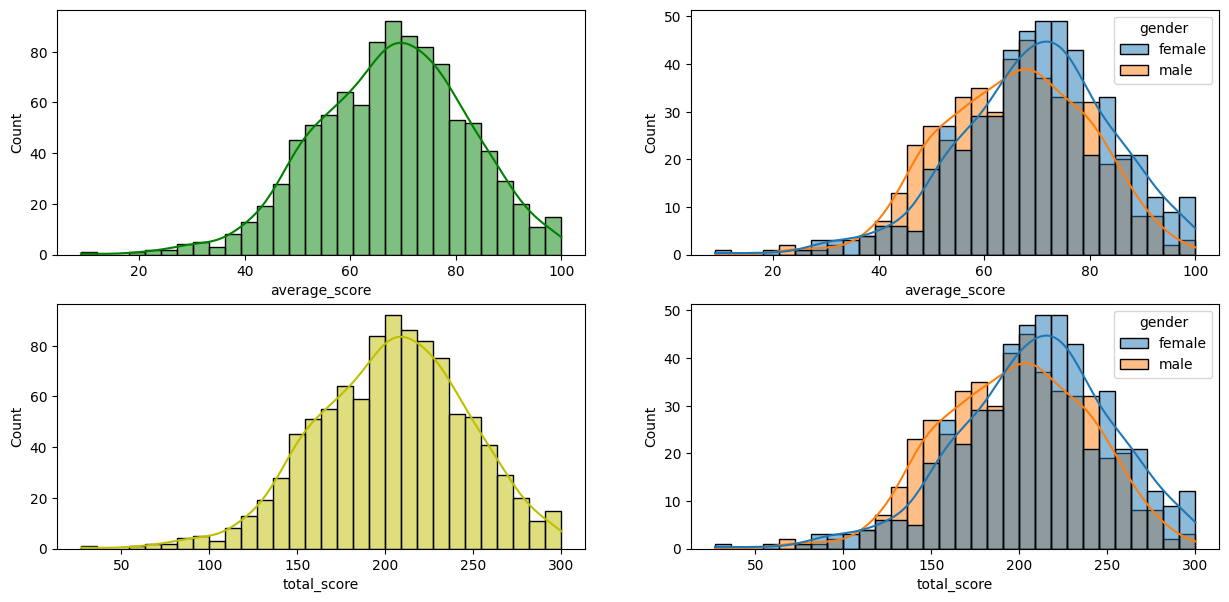

In [ ]:
# female perform better based on both total score and avg score

fig, axs = plt.subplots(2,2, figsize=(15,7))
sns.histplot(data=df, x="average_score", bins=30, kde=True, color='g', ax=axs[0,0])
sns.histplot(data=df, x="average_score", bins=30, kde=True,hue='gender', ax=axs[0,1])
sns.histplot(data=df, x="total_score", bins=30, kde=True, color='y', ax=axs[1,0])
sns.histplot(data=df, x="total_score", bins=30, kde=True,hue='gender', ax=axs[1,1])
plt.show()

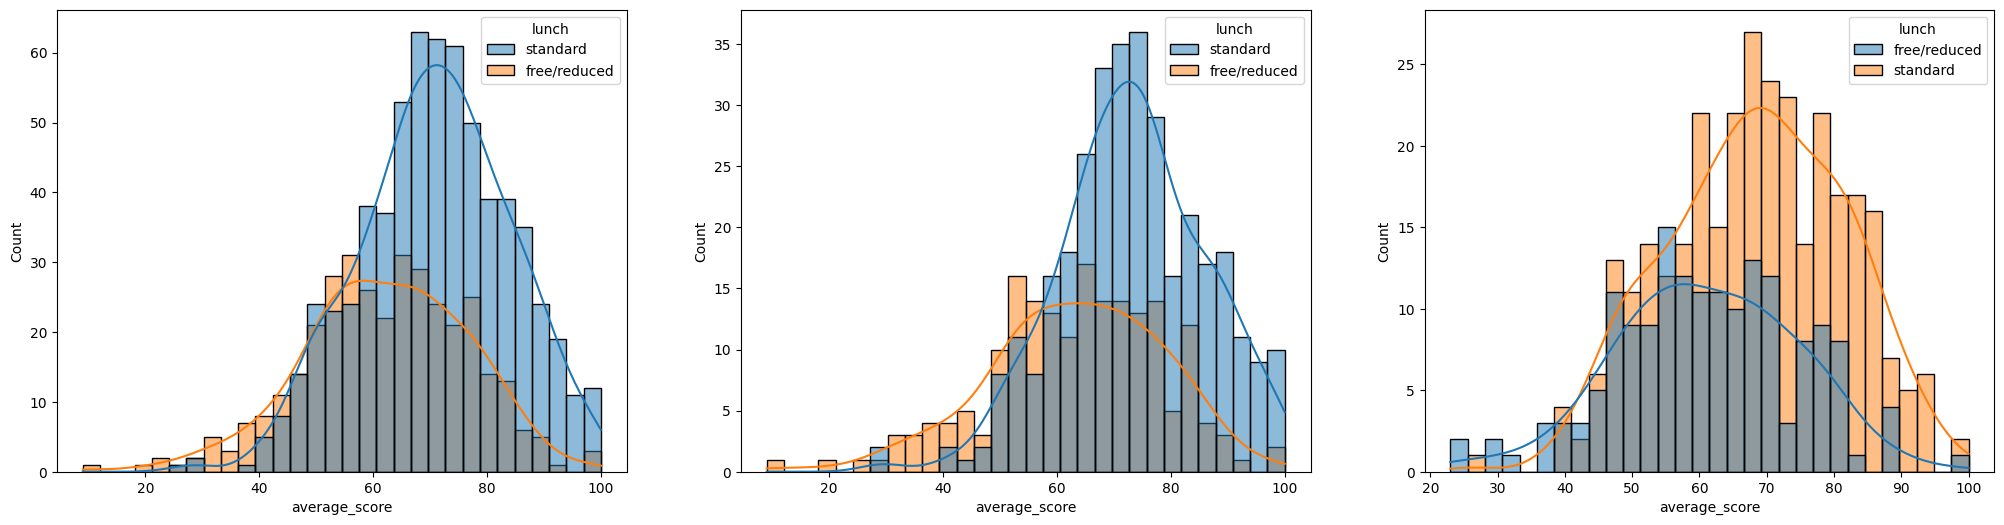

In [ ]:
# students eating standard food perform way better than free/reduced food students

fig, axs = plt.subplots(1,3, figsize=(25,6))
sns.histplot(data=df, x="average_score", bins=30, kde=True, hue='lunch', ax=axs[0])
sns.histplot(data=df[df.gender == 'female'], x="average_score", bins=30, kde=True, hue='lunch', ax=axs[1])
sns.histplot(data=df[df.gender == 'male'], x="average_score", bins=30, kde=True, hue='lunch', ax=axs[2])
plt.show()

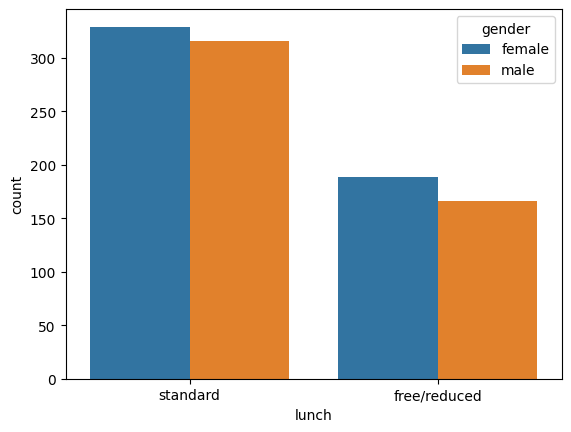

In [ ]:
# students eating standard food perform way better than free/reduced food students, split of free to standard food is similar 
# in both male and females

sns.countplot(data=df, x="lunch", hue='gender')
plt.show()

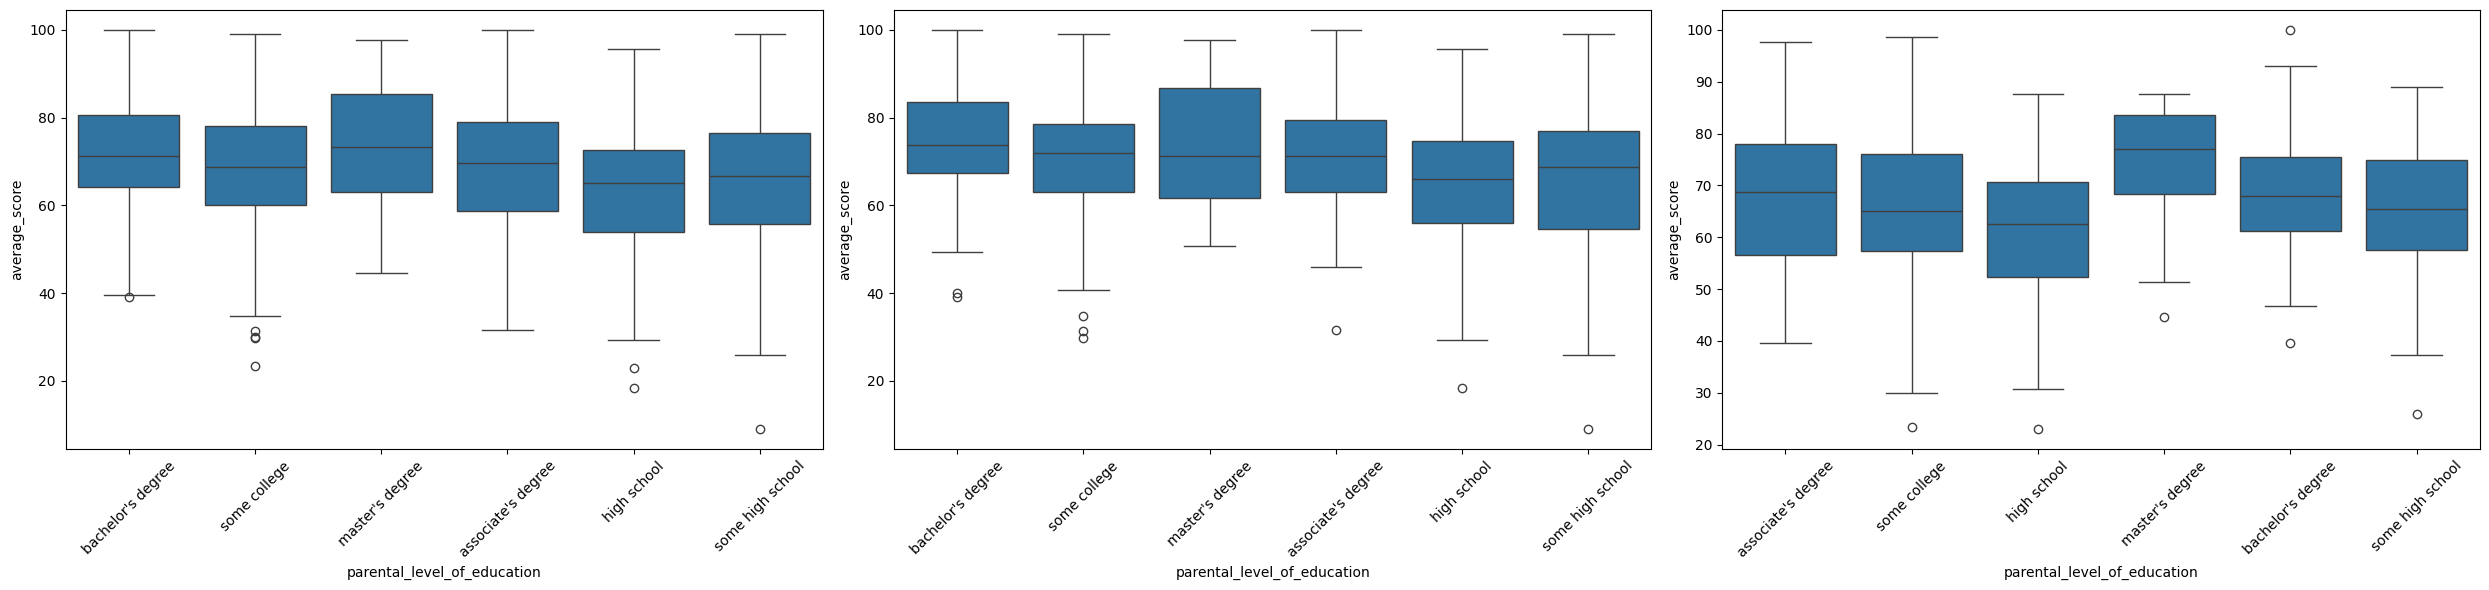

In [53]:
# not much to infer though, female students performance relatively independent of parents education, 
# male students perform better when parents are from masters/bachlors/associate

fig, axs = plt.subplots(1,3, figsize=(25,6))
sns.boxplot(data=df, x="parental_level_of_education",y="average_score", ax=axs[0])

sns.boxplot(data=df[df.gender == 'female'], x="parental_level_of_education",y="average_score", ax=axs[1])

sns.boxplot(data=df[df.gender == 'male'], x="parental_level_of_education",y="average_score", ax=axs[2])

for ax in axs:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


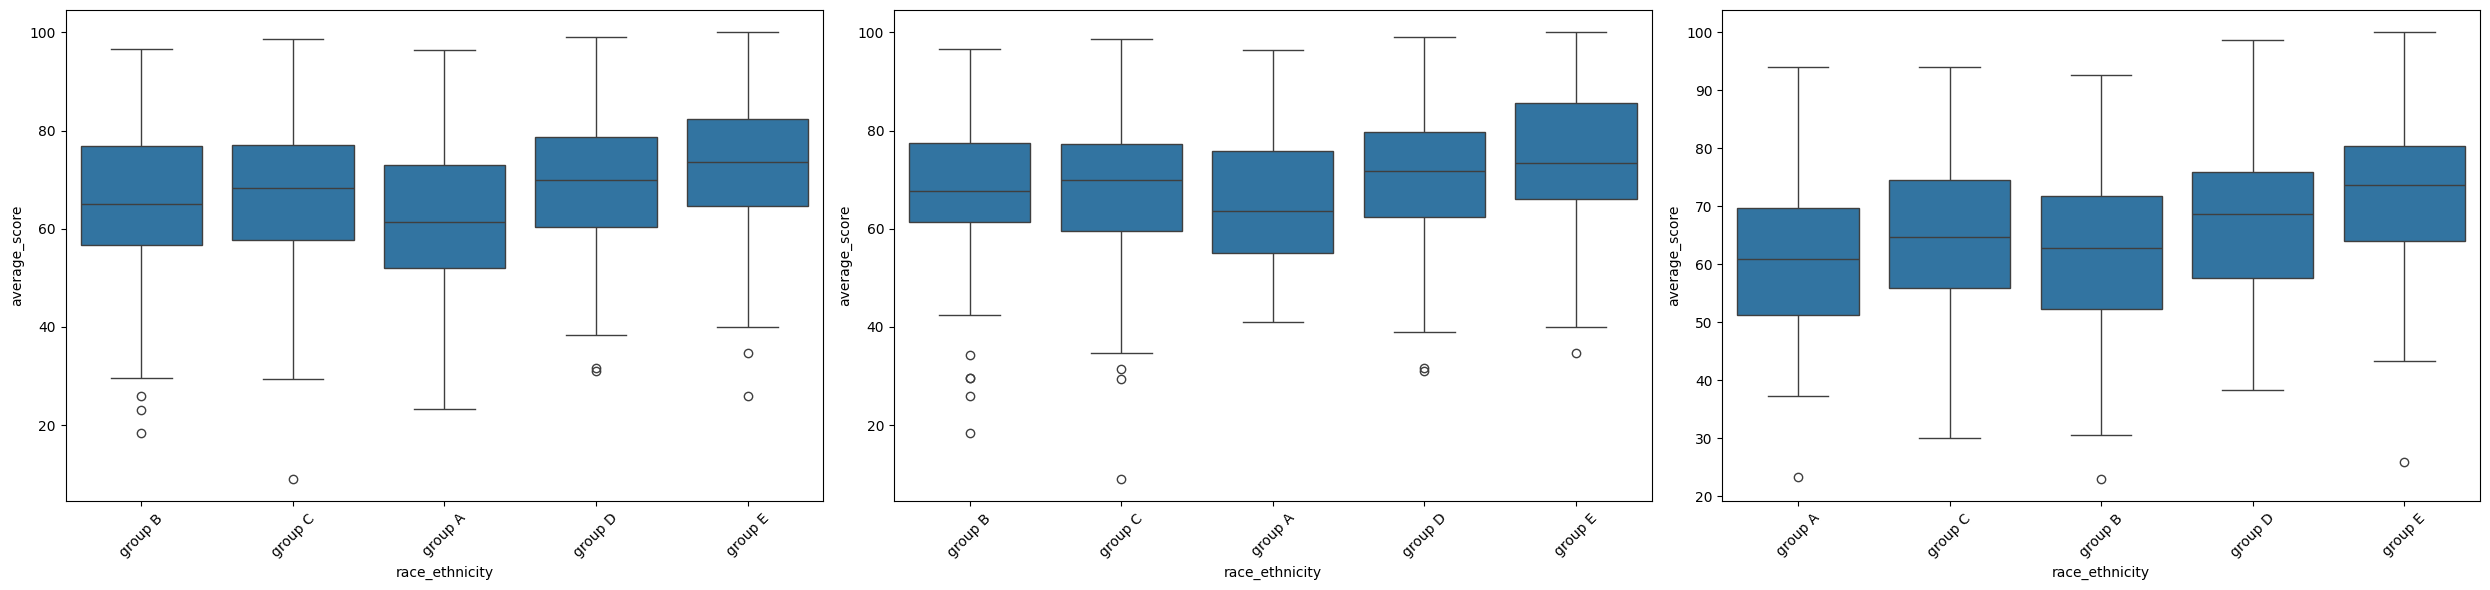

In [54]:
# performace of grp E > D > C > B > A in all plots, irrespective of genders

fig, axs = plt.subplots(1,3, figsize=(25,6))
sns.boxplot(data=df, x="race_ethnicity",y="average_score", ax=axs[0])

sns.boxplot(data=df[df.gender == 'female'], x="race_ethnicity",y="average_score", ax=axs[1])

sns.boxplot(data=df[df.gender == 'male'], x="race_ethnicity",y="average_score", ax=axs[2])

for ax in axs:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

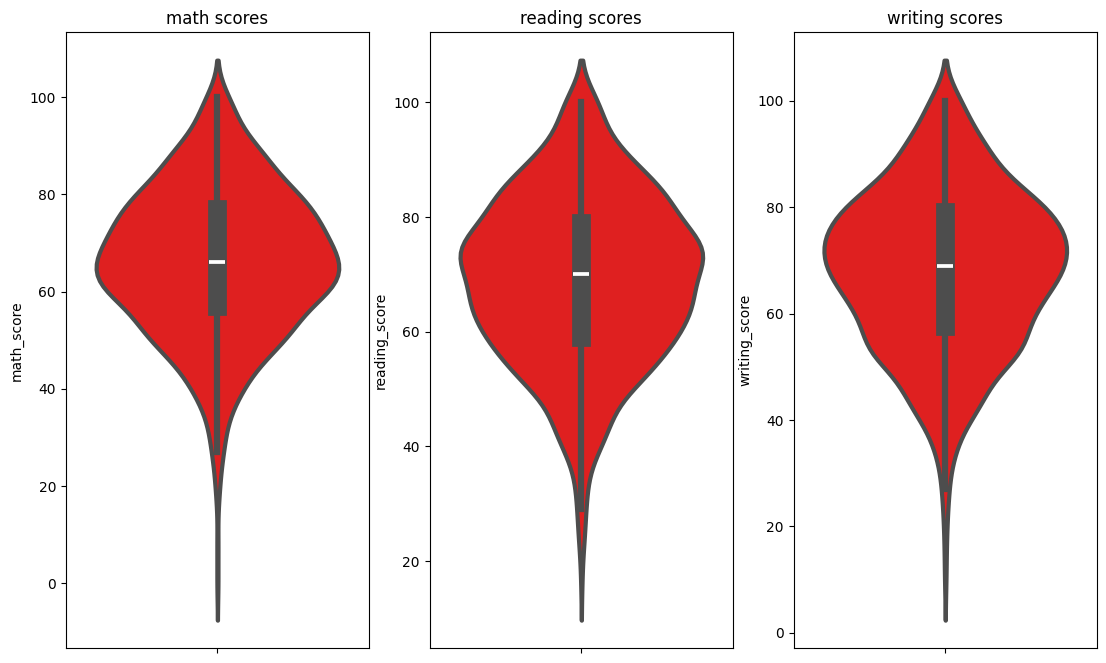

In [ ]:
# most students score between 60 to 80 in maths while 50 to 80 in other subjects

plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('math scores')
sns.violinplot(data=df,y="math_score",color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title('reading scores')
sns.violinplot(data=df,y="reading_score",color='red',linewidth=3)
plt.subplot(1,4,3)
plt.title('writing scores')
sns.violinplot(data=df,y="writing_score",color='red',linewidth=3)
plt.show()

#### Univariate and MultiVariate Analysis

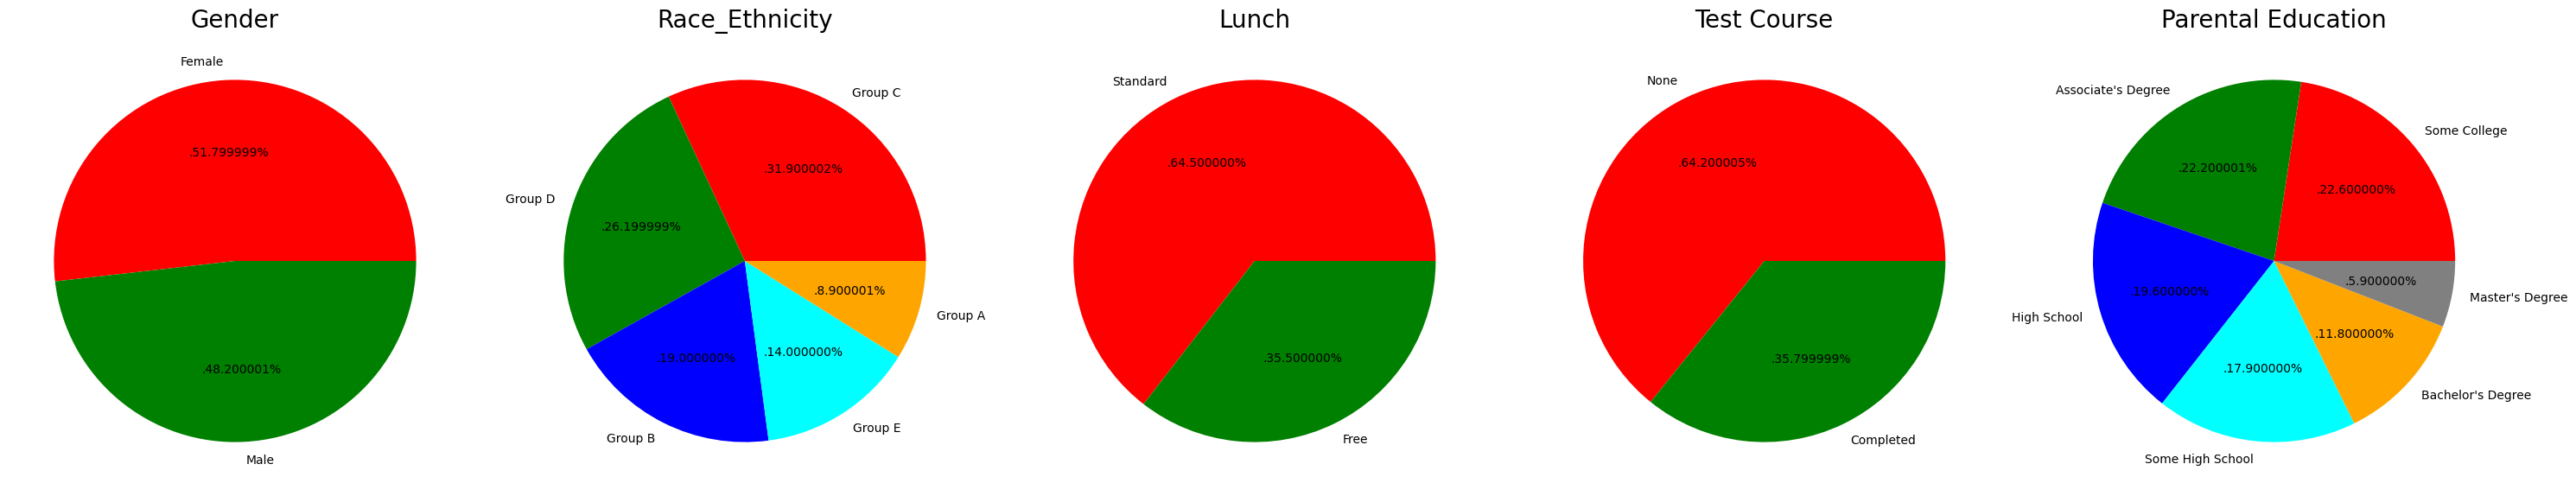

In [ ]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

# standard insights from the pie charts

In [ ]:
# we have seen distribution of gender, both are similar ~50%
# we know that females in general perform better wrt males

# math scores of females are less than male's while all other subjects, females dominate
gender_group = df.groupby('gender')[['math_score','reading_score','writing_score','total_score','average_score']].mean()
gender_group

,math_score,reading_score,writing_score,total_score,average_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


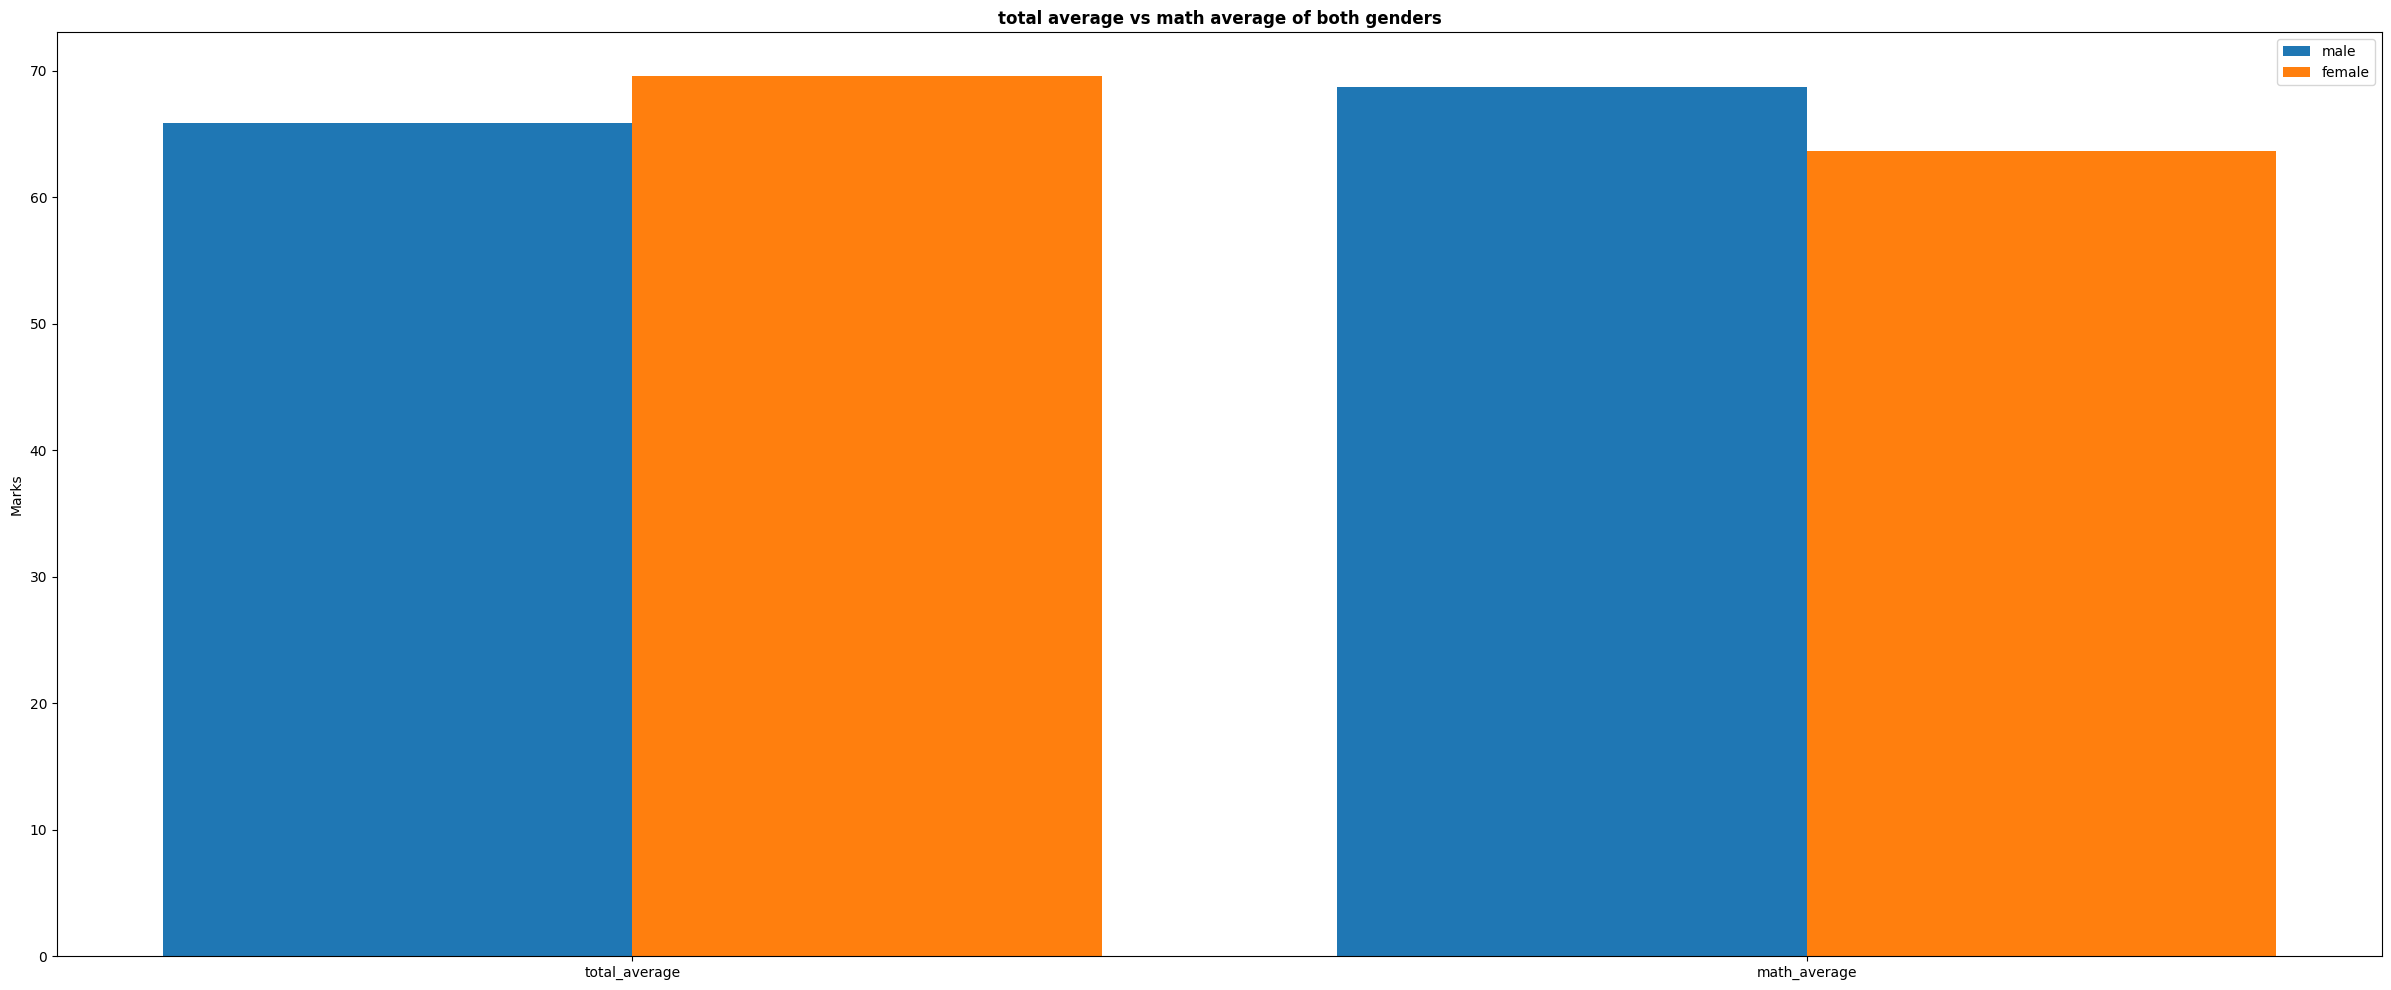

In [69]:
plt.Figure(figsize=(7,5))

X = ['total_average', 'math_average']

female_scores = [gender_group['average_score']['female'], gender_group['math_score']['female']]
male_scores = [gender_group['average_score']['male'], gender_group['math_score']['male']]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'female')

plt.xticks(X_axis, X)
plt.ylabel('Marks')
plt.title('total average vs math average of both genders', fontweight='bold')
plt.legend()
plt.show()


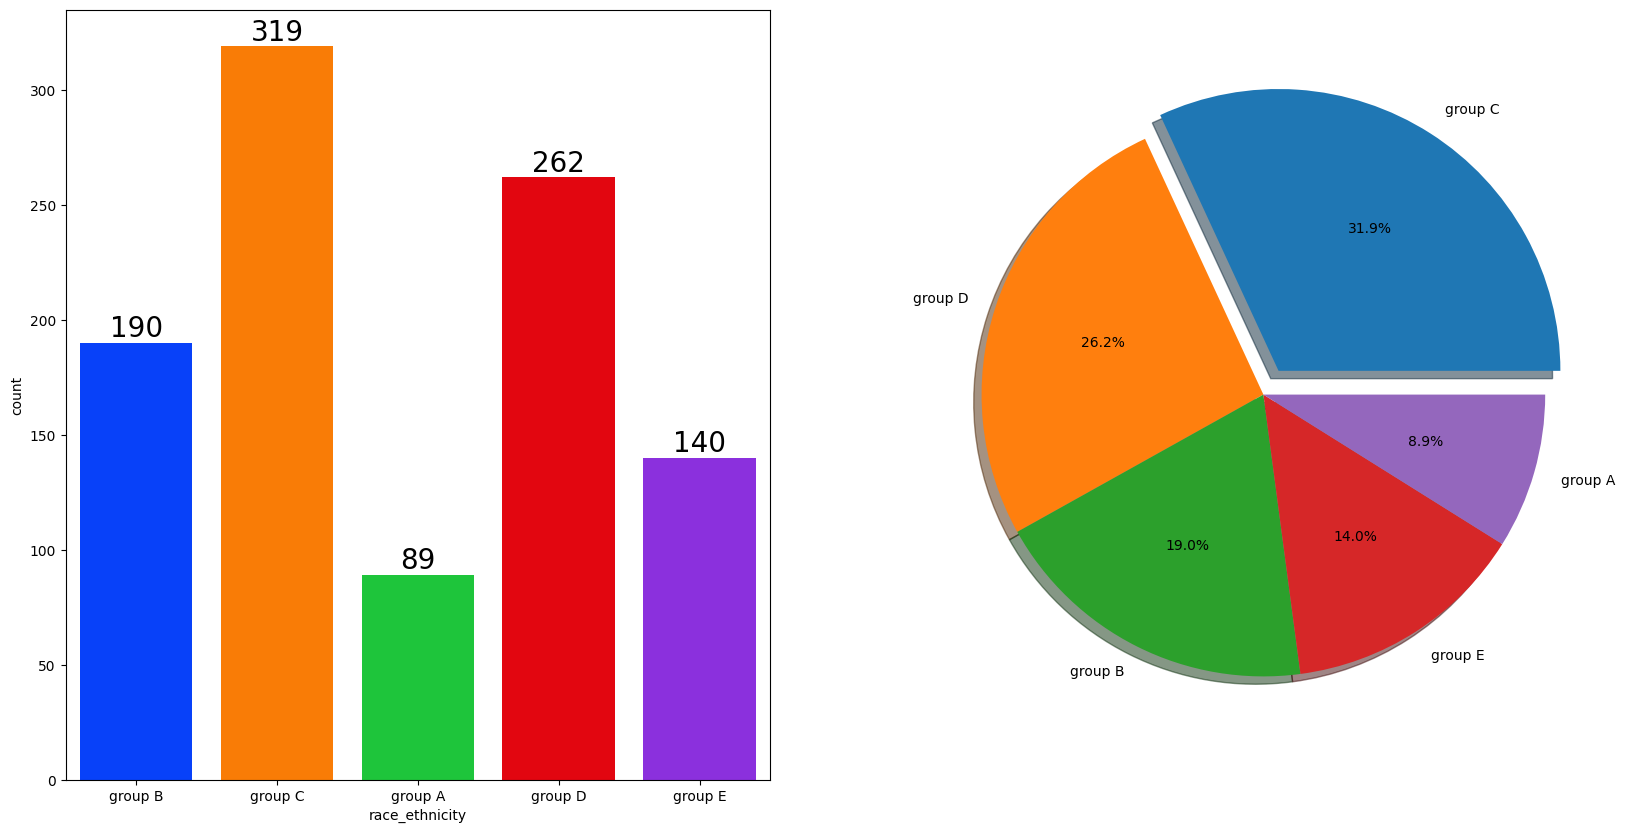

In [ ]:
# race/ethnicity

f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

# group A are the lowest among all the members while grp C are the highest

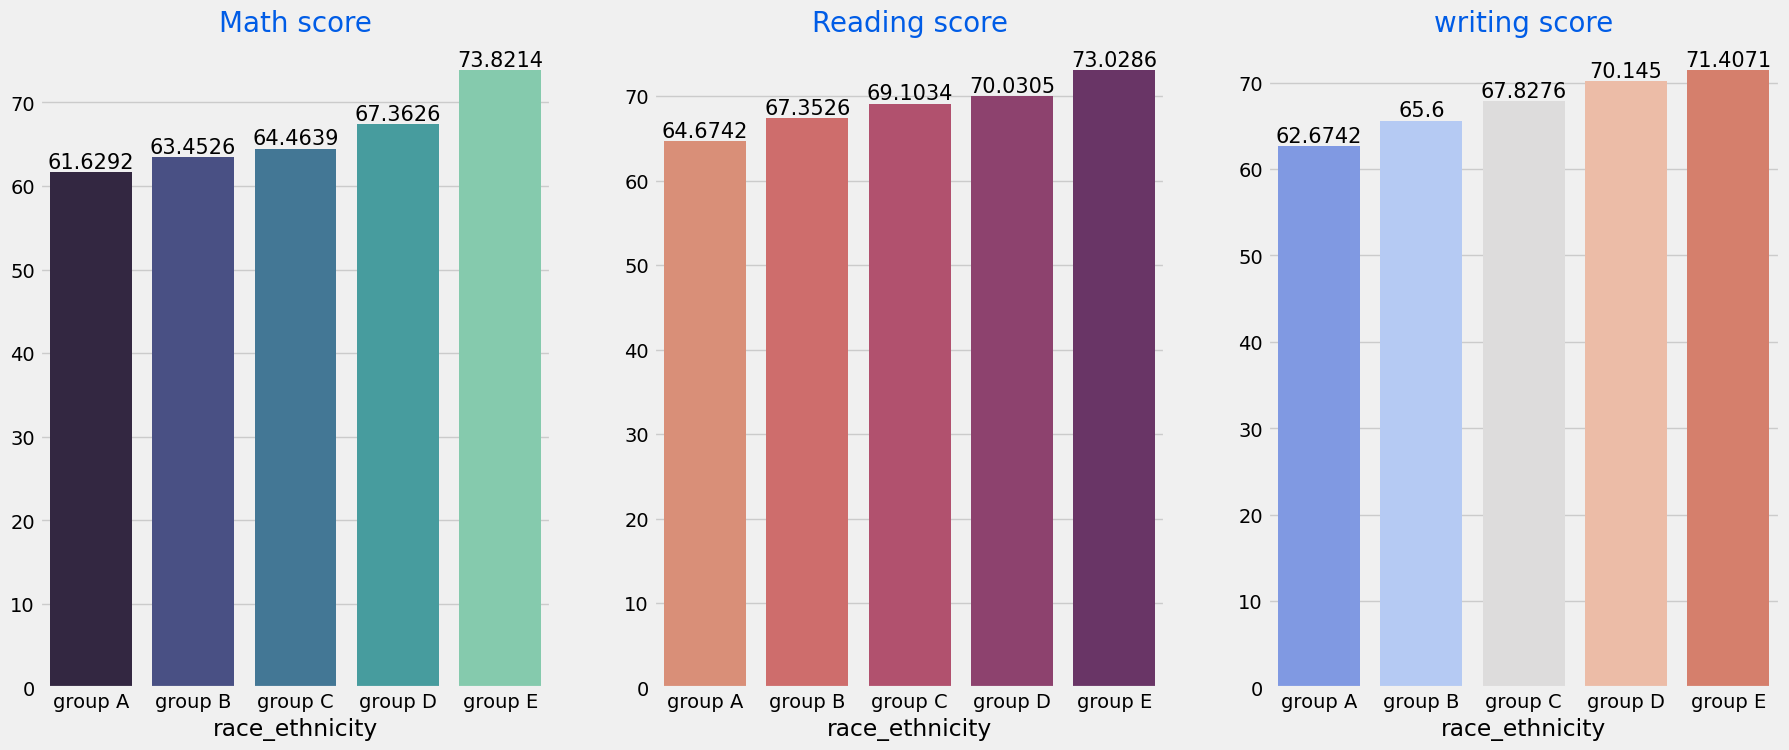

In [83]:
# same as the general trend grp E highest, grp A lowest (grp A being the lowest socio-economic status)

Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index, y =Group_data2['writing_score'].mean().values, palette = 'coolwarm', ax=ax[2])
ax[2].set_title('writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

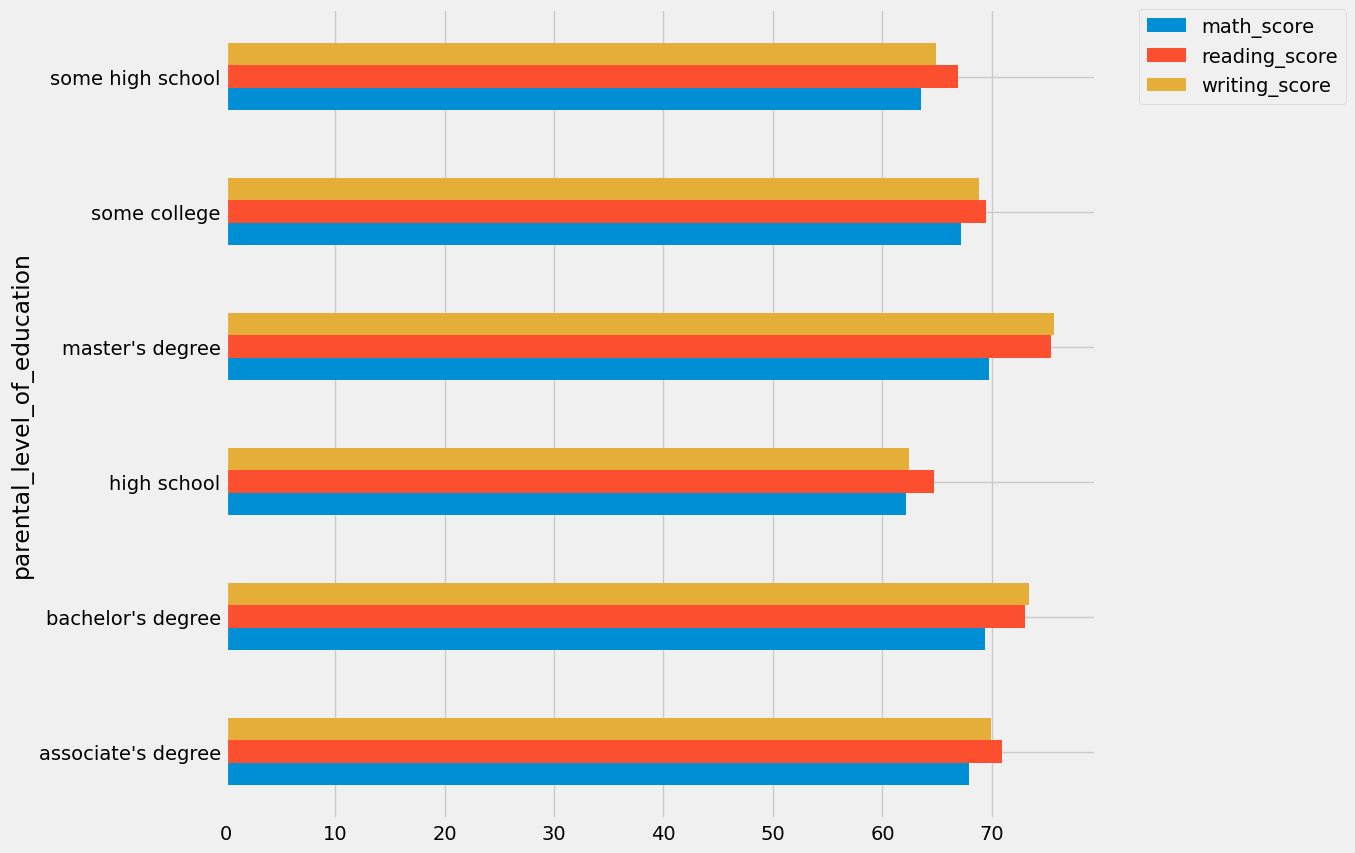

In [ ]:
# parents education distribution is already seen, also we know that students whose parents have masters have slightly high marks 
df.groupby('parental_level_of_education')[numerical_features].agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [ ]:
# we have seen that most of the students have standard lunch  (~64%)
# we also have seen that students who have standard lunch score higher than students who have free/reduced lunch

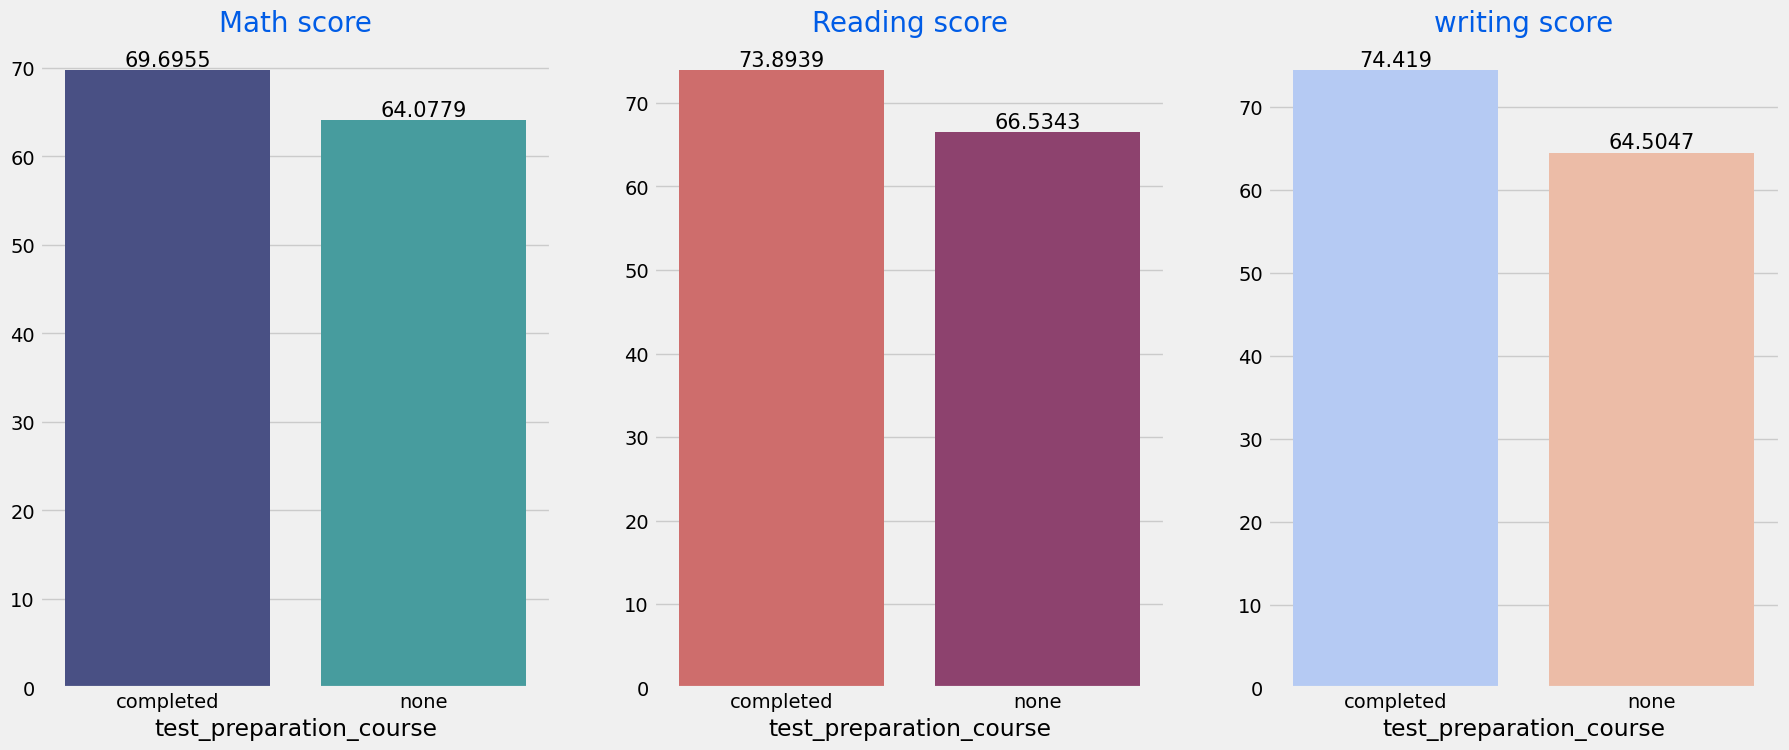

In [ ]:
# we know that ~64% of students have not taken any test prep series
# clearly, students who have completed the test preparation course, scored higher on average

Group_data2=df.groupby('test_preparation_course')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index, y =Group_data2['writing_score'].mean().values, palette = 'coolwarm', ax=ax[2])
ax[2].set_title('writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

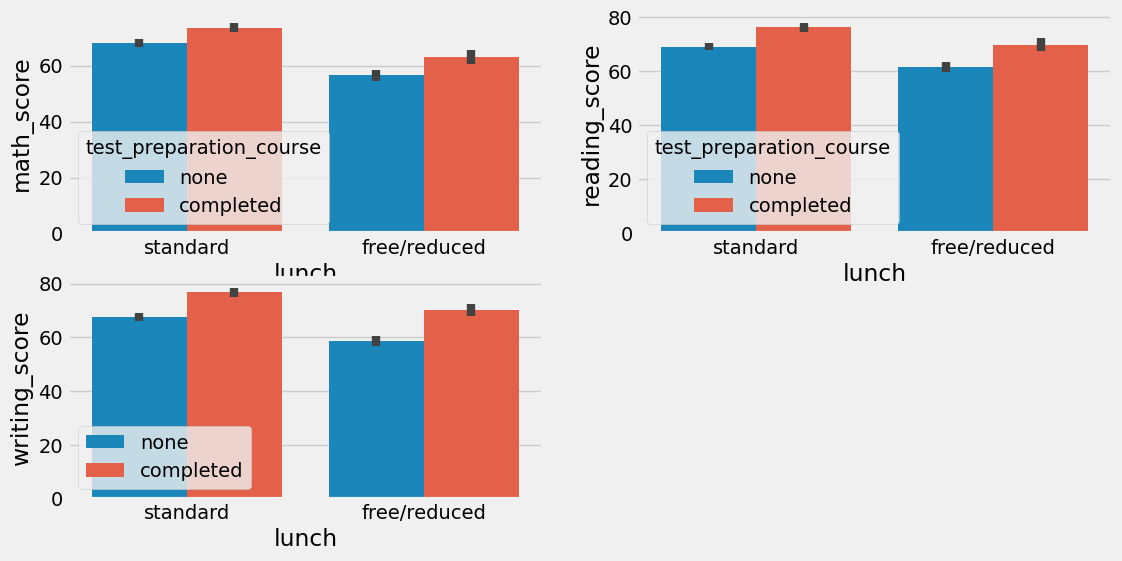

In [88]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])
plt.legend()
plt.show()

#### Checking for outliers

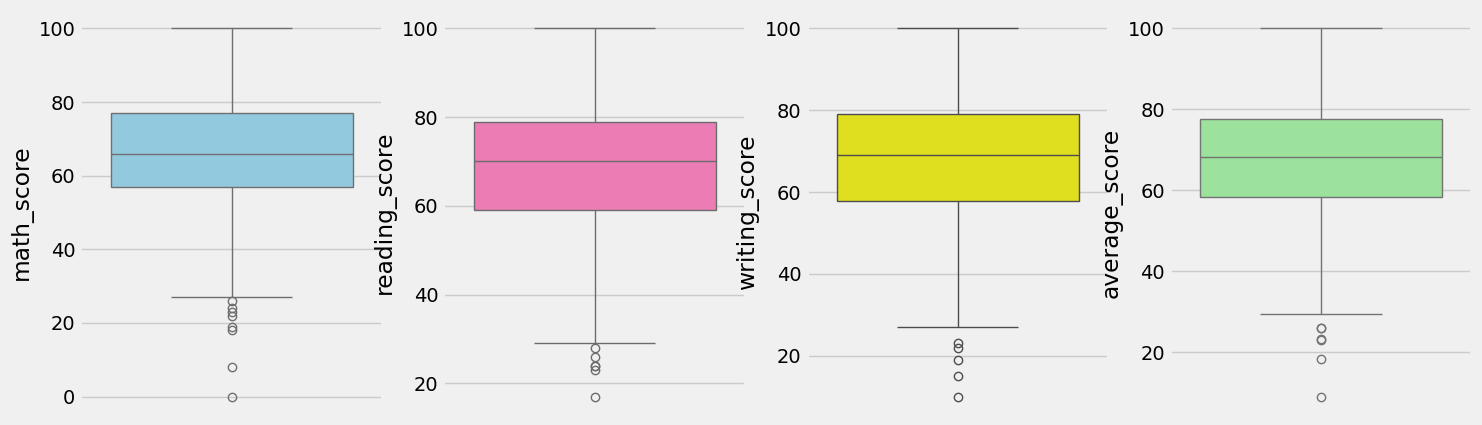

In [91]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

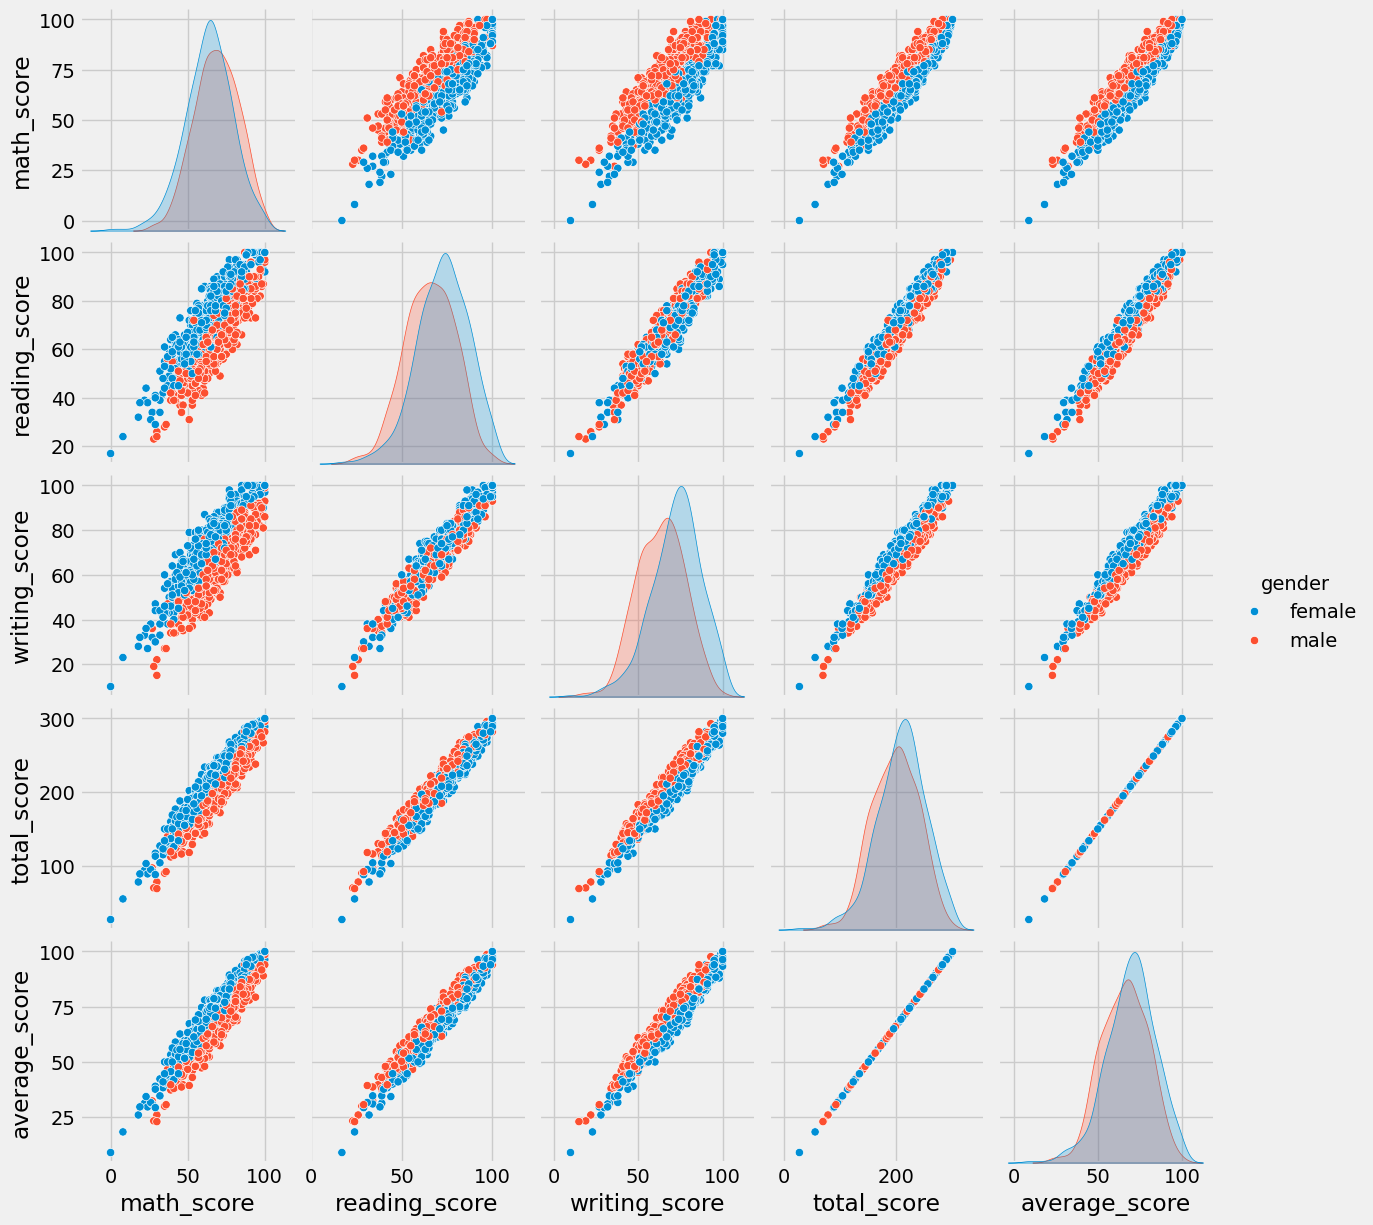

In [ ]:
# all the scores behave linearly, no complex relationships

sns.pairplot(df,hue = 'gender')
plt.show()

In [ ]:
### Final conclusions

# females perform better than male
# completion of test preparation leads to higher score
# scores are linearly related to other score
# having standard lunch results in better scores than free/reduced lunch
# parental education and race/social economic status supports higher scores as well